In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings("ignore")

In [2]:
#Data import
df=pd.read_csv("HR_Job_Placement_Dataset.csv")

In [3]:
df.head()

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status
0,27,Male,65.061656,83.842578,75.856526,Computer Science,58.221909,89.566305,64.474484,79.548913,...,5.805850,Tier 3,Not Matched,Medium,Not Required,15.0,No,18.0,Not Willing,Not Placed
1,24,Male,67.885626,64.973305,73.093588,Electronics,71.927978,54.591971,61.077306,73.316134,...,10.807739,Tier 1,Matched,High,Required,0.0,NaN,NaN,Not Willing,Not Placed
2,33,Female,73.892471,68.834121,90.196460,Information Technology,72.445041,58.587088,79.494739,75.466980,...,5.476839,Tier 3,Not Matched,Low,Not Required,0.0,No,3.0,Not Willing,Placed
3,31,Male,74.145568,76.255126,75.586731,Mechanical,78.855676,61.022065,53.740386,73.676449,...,9.980580,Tier 2,Matched,Low,Not Required,0.0,Yes,6.0,NaN,Not Placed
4,28,Male,60.475937,65.786336,80.801010,Information Technology,68.286776,65.713731,61.438314,88.994847,...,8.921233,Tier 2,Matched,Medium,Not Required,0.0,No,3.0,Willing,Not Placed


In [4]:
df.shape

(51500, 26)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51500 entries, 0 to 51499
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_years                  51500 non-null  int64  
 1   gender                     51500 non-null  object 
 2   ssc_percentage             48919 non-null  float64
 3   hsc_percentage             49435 non-null  float64
 4   degree_percentage          51500 non-null  float64
 5   degree_specialization      51500 non-null  object 
 6   technical_score            51500 non-null  float64
 7   aptitude_score             51500 non-null  float64
 8   communication_score        51500 non-null  float64
 9   skills_match_percentage    51500 non-null  float64
 10  certifications_count       51500 non-null  int64  
 11  internship_experience      51500 non-null  object 
 12  years_of_experience        51500 non-null  int64  
 13  career_switch_willingness  43034 non-null  obj

In [6]:
df.isnull().sum()

age_years                       0
gender                          0
ssc_percentage               2581
hsc_percentage               2065
degree_percentage               0
degree_specialization           0
technical_score                 0
aptitude_score                  0
communication_score             0
skills_match_percentage         0
certifications_count            0
internship_experience           0
years_of_experience             0
career_switch_willingness    8466
relevant_experience          8426
previous_ctc_lpa                0
expected_ctc_lpa                0
company_tier                    0
job_role_match               6131
competition_level               0
bond_requirement                0
notice_period_days           1582
layoff_history               8467
employment_gap_months        1097
relocation_willingness       8475
status                          0
dtype: int64

In [7]:
# ssc_percentage               2581
# hsc_percentage               2065
# career_switch_willingness    8466
# relevant_experience          8426
# job_role_match               6131
# notice_period_days           1582
# layoff_history               8467
# employment_gap_months        1097
# relocation_willingness       8475





In [8]:
df.columns

Index(['age_years', 'gender', 'ssc_percentage', 'hsc_percentage',
       'degree_percentage', 'degree_specialization', 'technical_score',
       'aptitude_score', 'communication_score', 'skills_match_percentage',
       'certifications_count', 'internship_experience', 'years_of_experience',
       'career_switch_willingness', 'relevant_experience', 'previous_ctc_lpa',
       'expected_ctc_lpa', 'company_tier', 'job_role_match',
       'competition_level', 'bond_requirement', 'notice_period_days',
       'layoff_history', 'employment_gap_months', 'relocation_willingness',
       'status'],
      dtype='object')

In [9]:
df.duplicated().sum()

np.int64(1376)

In [10]:
df[df.duplicated()]

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status
50000,29,Male,82.777504,55.403494,72.608382,Computer Science,85.730203,72.426358,51.770110,97.577679,...,9.093150,Tier 2,Matched,Medium,Not Required,15.0,No,0.0,Not Willing,Placed
50001,27,male,54.905068,80.120543,77.037600,Computer Science,54.166158,61.548708,65.307474,66.014409,...,7.292962,Tier 2,Matched,Low,Not Required,15.0,No,0.0,NaN,Not Placed
50003,21,Female,62.638945,60.735432,77.153040,Computer Science,59.987920,59.017158,56.717055,73.084570,...,7.108719,Tier 1,Matched,Low,Not Required,0.0,No,0.0,Not Willing,Not Placed
50004,25,Male,59.360622,70.230456,85.377955,Mechanical,65.678132,83.774928,79.334052,80.443948,...,10.555169,Tier 1,Matched,Low,Required,60.0,No,0.0,Not Willing,Not Placed
50005,22,Female,72.019465,79.009356,67.887885,Others,56.213118,73.397254,48.806828,91.301263,...,7.938697,Tier 1,Matched,Low,Not Required,60.0,No,12.0,Willing,Not Placed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51494,26,Female,69.562323,63.891266,75.931809,Computer Science,59.990409,51.169120,73.769113,68.913006,...,7.910303,Tier 2,NaN,Medium,Not Required,0.0,No,6.0,Not Willing,Not Placed
51495,24,Female,65.747180,72.063946,72.247881,Electronics,55.923057,73.208032,69.108895,63.992488,...,6.315211,Tier 1,Matched,Low,Required,0.0,No,3.0,NaN,Not Placed
51496,22,Male,61.921459,66.729203,55.000000,Others,69.525121,70.245612,54.959868,88.514232,...,8.655391,Tier 1,Matched,Medium,Not Required,60.0,No,0.0,Not Willing,Placed
51498,29,Female,77.327209,56.629227,69.735374,Mechanical,48.270078,61.171900,71.650243,76.318681,...,9.617279,Tier 2,Matched,Medium,Not Required,0.0,Yes,0.0,Willing,Not Placed


In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.shape

(50124, 26)

In [13]:
df['status'].value_counts()


status
Not Placed    34950
Placed        15174
Name: count, dtype: int64

In [14]:
df['status'].value_counts(normalize=True) * 100


status
Not Placed    69.727077
Placed        30.272923
Name: proportion, dtype: float64

In [15]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object','bool']).columns

num_cols, cat_cols


(Index(['age_years', 'ssc_percentage', 'hsc_percentage', 'degree_percentage',
        'technical_score', 'aptitude_score', 'communication_score',
        'skills_match_percentage', 'certifications_count',
        'years_of_experience', 'previous_ctc_lpa', 'expected_ctc_lpa',
        'notice_period_days', 'employment_gap_months'],
       dtype='object'),
 Index(['gender', 'degree_specialization', 'internship_experience',
        'career_switch_willingness', 'relevant_experience', 'company_tier',
        'job_role_match', 'competition_level', 'bond_requirement',
        'layoff_history', 'relocation_willingness', 'status'],
       dtype='object'))

In [16]:
#replacing null value with median for numeric fields

num_cols = [
    'ssc_percentage',
    'hsc_percentage',
    'notice_period_days',
    'employment_gap_months'
]

df[num_cols] = df[num_cols].fillna(df[num_cols].median())


In [17]:
#replaceing null value with mode for categorial data

cat_cols = [
    'career_switch_willingness',
    'relevant_experience',
    'job_role_match',
    'layoff_history',
    'relocation_willingness'
]

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


In [18]:
df.isnull().sum()


age_years                    0
gender                       0
ssc_percentage               0
hsc_percentage               0
degree_percentage            0
degree_specialization        0
technical_score              0
aptitude_score               0
communication_score          0
skills_match_percentage      0
certifications_count         0
internship_experience        0
years_of_experience          0
career_switch_willingness    0
relevant_experience          0
previous_ctc_lpa             0
expected_ctc_lpa             0
company_tier                 0
job_role_match               0
competition_level            0
bond_requirement             0
notice_period_days           0
layoff_history               0
employment_gap_months        0
relocation_willingness       0
status                       0
dtype: int64

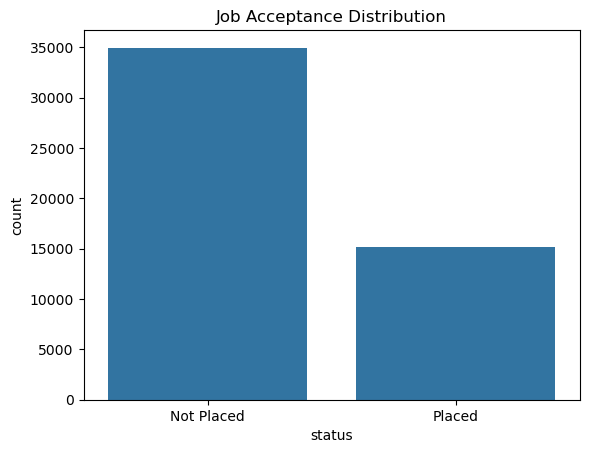

In [19]:
#EDA Process
# Target Variable Distribution
sns.countplot(x='status', data=df)
plt.title('Job Acceptance Distribution')
plt.show()


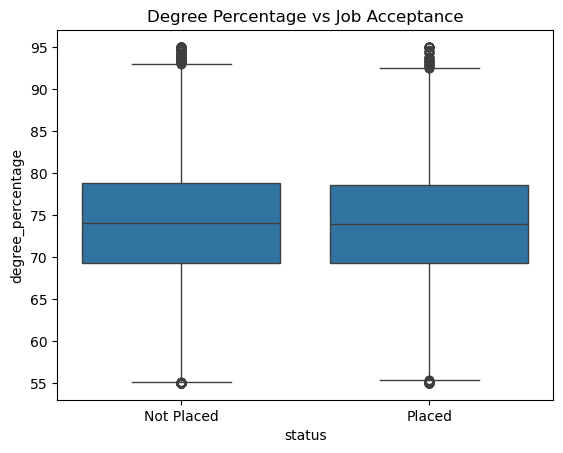

In [20]:
# Academic Performance vs Job Acceptance
sns.boxplot(x='status', y='degree_percentage', data=df)
plt.title('Degree Percentage vs Job Acceptance')
plt.show()


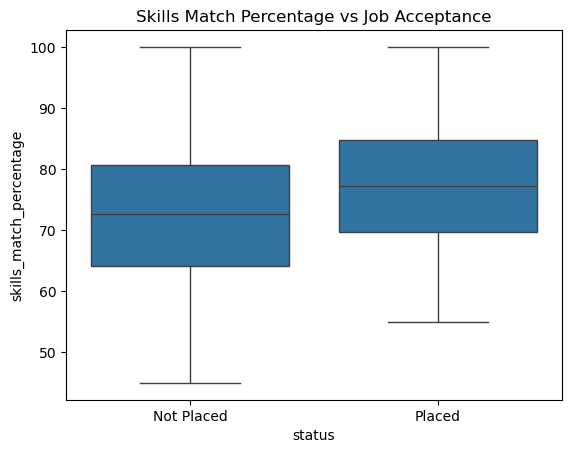

In [21]:
# Skills Match vs Job Acceptance
sns.boxplot(x='status', y='skills_match_percentage', data=df)
plt.title('Skills Match Percentage vs Job Acceptance')
plt.show()


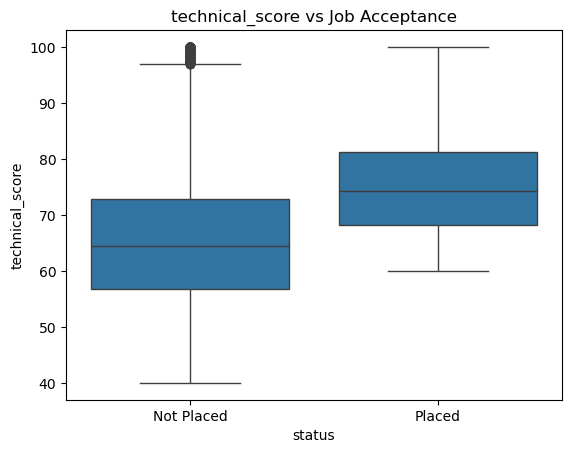

In [22]:
sns.boxplot(x='status', y='technical_score', data=df)
plt.title('technical_score vs Job Acceptance')
plt.show()

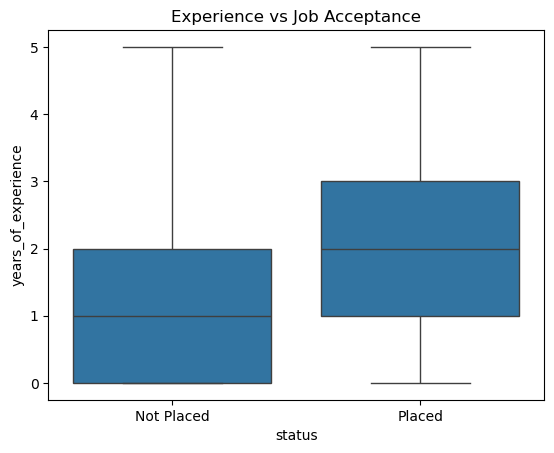

In [23]:
# Experience vs Job Acceptance
sns.boxplot(x='status', y='years_of_experience', data=df)
plt.title('Experience vs Job Acceptance')
plt.show()


In [24]:
df['company_tier'] = df['company_tier'].str.strip().str.title()


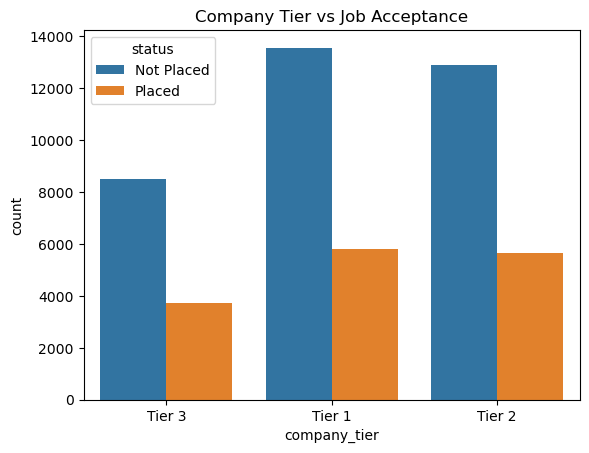

In [25]:
# Company Tier vs Acceptance Rate
sns.countplot(x='company_tier', hue='status', data=df)
plt.title('Company Tier vs Job Acceptance')
plt.show()


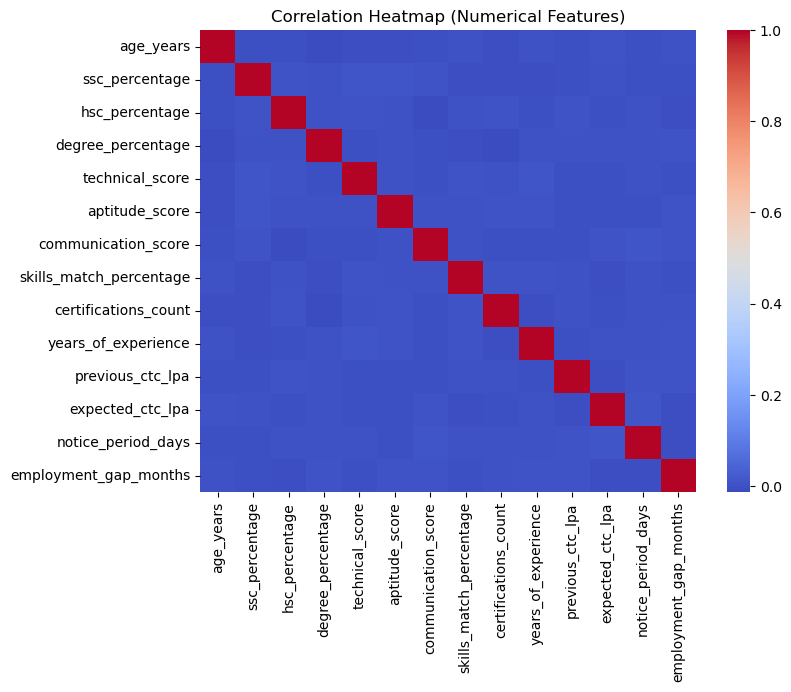

In [26]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()


In [27]:
# Feature Engineering
# ●	Experience category (Fresher / Junior / Senior)
def experience_category(x):
    if x == 0:
        return 'Fresher'
    elif x <= 2:
        return 'Junior'
    else:
        return 'Senior'

df['experience_category'] = df['years_of_experience'].apply(experience_category)


In [28]:
# ●	Academic performance bands
df['academic_band'] = pd.cut(
    df['degree_percentage'],
    bins=[0, 60, 75, 100],
    labels=['Low', 'Medium', 'High']
)


In [29]:
# Skills Match Level
df['skills_level'] = pd.cut(
    df['skills_match_percentage'],
    bins=[0, 60, 80, 100],
    labels=['Low', 'Medium', 'High']
)


In [30]:
# ●	Interview performance category
df['interview_score'] = df[
    ['technical_score', 'aptitude_score', 'communication_score']
].mean(axis=1)


In [31]:
# ●	Placement probability score
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['degree_norm',
    'skills_norm',
    'interview_norm',
    'experience_norm']] = scaler.fit_transform(
    df[['degree_percentage',
        'skills_match_percentage',
        'interview_score',
        'years_of_experience']]
)


In [32]:
df['status']

0        Not Placed
1        Not Placed
2            Placed
3        Not Placed
4        Not Placed
            ...    
51475    Not Placed
51480    Not Placed
51484    Not Placed
51488        Placed
51497        Placed
Name: status, Length: 50124, dtype: object

In [33]:
df['status'] = df['status'].map({
    'Not Placed': 0,
    'Placed': 1
})

In [34]:
# ML
X = df.drop('status', axis=1)
y = df['status']



In [35]:
df['status']

0        0
1        0
2        1
3        0
4        0
        ..
51475    0
51480    0
51484    0
51488    1
51497    1
Name: status, Length: 50124, dtype: int64

In [36]:
# Distribution of data(moderately imbalanced)
print("Target Distribution (Count):")
print(y.value_counts())

print("\nTarget Distribution (Percentage):")
print(y.value_counts(normalize=True) * 100)

Target Distribution (Count):
status
0    34950
1    15174
Name: count, dtype: int64

Target Distribution (Percentage):
status
0    69.727077
1    30.272923
Name: proportion, dtype: float64


In [37]:
X_manual = X.copy()

# Clean text columns
cols_to_clean = [
    'gender',
    'job_role_match',
    'relocation_willingness',
    'career_switch_willingness',
    'bond_requirement',
    'internship_experience'
]

for col in cols_to_clean:
    X_manual[col] = (
        X_manual[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

In [38]:
X_manual['gender'] = X_manual['gender'].map({
    'male': 1,
    'female': 0
})

X_manual['job_role_match'] = X_manual['job_role_match'].map({
    'matched': 1,
    'not matched': 0
})

X_manual['relocation_willingness'] = X_manual['relocation_willingness'].map({
    'willing': 1,
    'not willing': 0
})

X_manual['career_switch_willingness'] = X_manual['career_switch_willingness'].map({
    'willing': 1,
    'not willing': 0
})

X_manual['degree_specialization'] = X_manual['degree_specialization'].map({
     'Information Technology':3,
    'Computer Science': 0,
    'Electronics': 1,
    'Mechanical':2,
    'Others':4
   
})
X_manual['internship_experience'] = X_manual['internship_experience'].map({
    'yes': 0,
    'no': 1
})

X_manual['relevant_experience'] = X_manual['relevant_experience'].map({
    'Relevant': 1,
    'Not Relevant': 0
})


X_manual['layoff_history'] = X_manual['layoff_history'].map({
    'Yes': 0,
    'No': 1
})


X_manual['company_tier'] = X_manual['company_tier'].map({
    'Tier 3': 1,
    'Tier 1': 3,
    'Tier 2':2
})

X_manual['competition_level'] = X_manual['competition_level'].map({
    'Low': 1,
    'High': 3,
    'Medium':2
})

X_manual['bond_requirement'] = X_manual['bond_requirement'].map({
    'not required': 0,
    'required': 1
})

X_manual['experience_category'] = X_manual['experience_category'].map({
    'Junior': 1,
    'Senior': 2,
    'Fresher':0
})

X_manual['academic_band'] = X_manual['academic_band'].map({
    'Medium': 1,
    'High': 2,
    'Low':0
})

X_manual['skills_level'] = X_manual['skills_level'].map({
    'Medium': 1,
    'Low': 0,
    'High':2
})

In [39]:
X_manual

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,employment_gap_months,relocation_willingness,experience_category,academic_band,skills_level,interview_score,degree_norm,skills_norm,interview_norm,experience_norm
0,27,1,65.061656,83.842578,75.856526,0,58.221909,89.566305,64.474484,79.548913,...,18.0,0,1,2,1,70.754233,0.521413,0.628162,0.549789,0.2
1,24,1,67.885626,64.973305,73.093588,1,71.927978,54.591971,61.077306,73.316134,...,0.0,0,0,1,1,62.532418,0.452340,0.514839,0.383482,0.0
2,33,0,73.892471,68.834121,90.196460,3,72.445041,58.587088,79.494739,75.466980,...,3.0,0,1,2,1,70.175622,0.879911,0.553945,0.538085,0.2
3,31,1,74.145568,76.255126,75.586731,2,78.855676,61.022065,53.740386,73.676449,...,6.0,1,0,2,1,64.539376,0.514668,0.521390,0.424078,0.0
4,28,1,60.475937,65.786336,80.801010,3,68.286776,65.713731,61.438314,88.994847,...,3.0,1,0,2,2,65.146274,0.645025,0.799906,0.436354,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51475,33,1,59.202809,70.381922,64.194312,0,58.749055,70.892920,66.256945,64.288988,...,0.0,1,0,1,1,65.299640,0.229858,0.350709,0.439456,0.0
51480,26,0,59.085833,68.795821,82.025453,2,67.147475,67.903147,72.304220,70.019765,...,0.0,1,1,2,1,69.118281,0.675636,0.454905,0.516698,0.4
51484,23,1,66.290959,75.552994,66.761658,4,64.135029,65.579632,68.462568,100.000000,...,0.0,0,1,1,2,66.059076,0.294041,1.000000,0.454818,0.4
51488,24,0,72.151163,63.397535,67.094174,0,60.228937,72.189740,89.993044,72.266721,...,0.0,1,2,1,1,74.137240,0.302354,0.495759,0.618219,0.6


In [40]:
# trin test plit

X_train, X_test, y_train, y_test = train_test_split(
    X_manual, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # important for classification
)

In [41]:
# LogisticRegression
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000,class_weight='balanced')

model_lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [42]:
# Make Predictions
# Predict on test data
y_pred_lr = model_lr.predict(X_test)

# Check first 10 predictions
y_pred_lr[:10]

array([0, 1, 0, 1, 0, 1, 0, 0, 1, 0])

In [43]:
# Check Accuracy
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8531670822942643


In [44]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix:\n", cm_lr)

Confusion Matrix:
 [[5905 1085]
 [ 387 2648]]


In [45]:
# Classification Report ( evaluation metrics )
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.94      0.84      0.89      6990
           1       0.71      0.87      0.78      3035

    accuracy                           0.85     10025
   macro avg       0.82      0.86      0.84     10025
weighted avg       0.87      0.85      0.86     10025



In [46]:
from sklearn.metrics import recall_score

In [47]:
lr_recall = recall_score(y_test, y_pred_lr, pos_label=1)

In [48]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42,class_weight='balanced')

model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)
dt_recall = recall_score(y_test, y_pred_dt, pos_label=1)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8268329177057356
[[6129  861]
 [ 875 2160]]
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      6990
           1       0.71      0.71      0.71      3035

    accuracy                           0.83     10025
   macro avg       0.80      0.79      0.79     10025
weighted avg       0.83      0.83      0.83     10025



In [49]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced')

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
rf_recall = recall_score(y_test, y_pred_rf, pos_label=1)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.886284289276808
[[6607  383]
 [ 757 2278]]
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      6990
           1       0.86      0.75      0.80      3035

    accuracy                           0.89     10025
   macro avg       0.88      0.85      0.86     10025
weighted avg       0.88      0.89      0.88     10025



In [50]:
# Compare All Models


results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
     "Recall (Placed)": [lr_recall, dt_recall, rf_recall]
})

results.sort_values(by="Recall (Placed)", ascending=False)
results

,Model,Accuracy,Recall (Placed)
0,Logistic Regression,0.853167,0.872488
1,Decision Tree,0.826833,0.711697
2,Random Forest,0.886284,0.750577


In [51]:
# Selecting Random Forest Model as Final

# Final Evaluation

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.886284289276808

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.92      6990
           1       0.86      0.75      0.80      3035

    accuracy                           0.89     10025
   macro avg       0.88      0.85      0.86     10025
weighted avg       0.88      0.89      0.88     10025


Confusion Matrix:
 [[6607  383]
 [ 757 2278]]


In [52]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    model_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance)

technical_score              0.194219
interview_score              0.069047
interview_norm               0.067229
expected_ctc_lpa             0.057242
skills_match_percentage      0.050216
skills_norm                  0.050117
years_of_experience          0.049960
experience_norm              0.044318
job_role_match               0.038873
previous_ctc_lpa             0.036827
aptitude_score               0.031951
experience_category          0.031944
communication_score          0.028658
internship_experience        0.023536
hsc_percentage               0.023136
ssc_percentage               0.023131
degree_percentage            0.021228
degree_norm                  0.021215
age_years                    0.015632
skills_level                 0.014342
relevant_experience          0.012856
employment_gap_months        0.012472
layoff_history               0.012181
notice_period_days           0.010791
certifications_count         0.009802
degree_specialization        0.009279
competition_

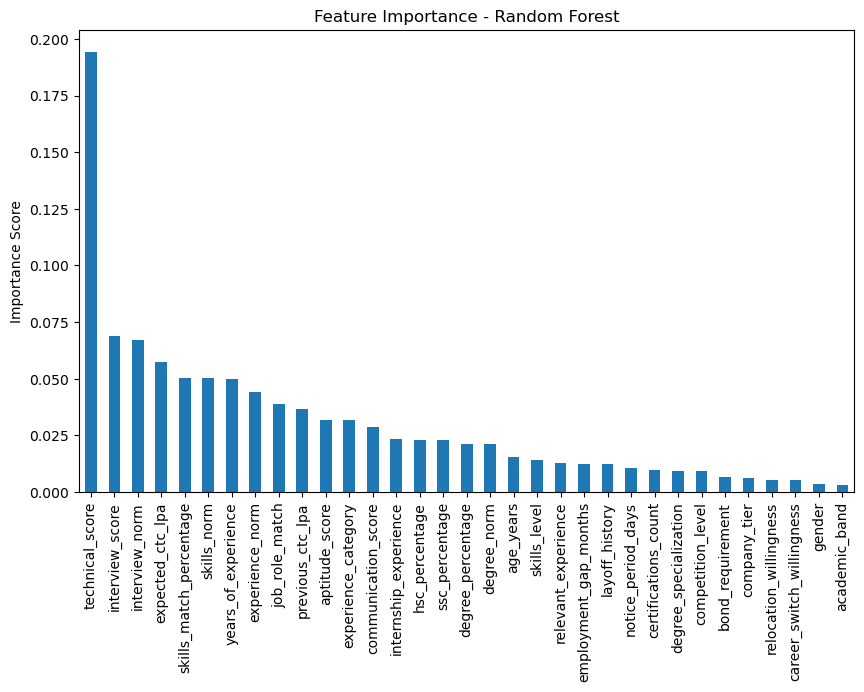

In [53]:
plt.figure(figsize=(10,6))
feature_importance.plot(kind='bar')
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance Score")
plt.show()

In [54]:
# Apply Cutoff (Importance > 0.01
# Select features with importance greater than 0.01
cutoff_value = 0.01

selected_features = feature_importance[
    feature_importance > cutoff_value
].index.tolist()

print("Cutoff Used:", cutoff_value)
print("\nNumber of Selected Features:", len(selected_features))
print("\nSelected Features:")
print(selected_features)

Cutoff Used: 0.01

Number of Selected Features: 24

Selected Features:
['technical_score', 'interview_score', 'interview_norm', 'expected_ctc_lpa', 'skills_match_percentage', 'skills_norm', 'years_of_experience', 'experience_norm', 'job_role_match', 'previous_ctc_lpa', 'aptitude_score', 'experience_category', 'communication_score', 'internship_experience', 'hsc_percentage', 'ssc_percentage', 'degree_percentage', 'degree_norm', 'age_years', 'skills_level', 'relevant_experience', 'employment_gap_months', 'layoff_history', 'notice_period_days']


In [55]:
# Create Dataset with Selected Features Only
# Keep only selected features
X_selected = X_manual[selected_features]

print("Original Feature Count:", X.shape[1])
print("Reduced Feature Count:", X_selected.shape[1])

Original Feature Count: 33
Reduced Feature Count: 24


In [56]:
# Train Test Split Again
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [57]:
X_train_sel

,technical_score,interview_score,interview_norm,expected_ctc_lpa,skills_match_percentage,skills_norm,years_of_experience,experience_norm,job_role_match,previous_ctc_lpa,...,hsc_percentage,ssc_percentage,degree_percentage,degree_norm,age_years,skills_level,relevant_experience,employment_gap_months,layoff_history,notice_period_days
43124,59.254504,61.185348,0.356235,8.081936,72.294333,0.496261,1,0.2,1,1.014166,...,60.589040,50.000000,73.018035,0.450451,21,1,1,0.0,1,15.0
26110,58.110485,53.534544,0.201478,6.254704,48.281428,0.059662,4,0.8,1,7.063488,...,73.298243,69.935716,61.411902,0.160298,32,0,0,0.0,1,0.0
11576,50.782648,67.720497,0.488424,13.085389,55.419806,0.189451,3,0.6,1,2.391365,...,76.080461,66.534135,78.108183,0.577705,21,0,1,3.0,1,30.0
45273,71.197427,66.705209,0.467887,11.500157,62.804261,0.323714,1,0.2,1,3.578214,...,75.592319,59.729692,79.552148,0.613804,32,1,1,0.0,1,0.0
32035,88.574328,71.881800,0.572597,10.161817,75.095574,0.547192,1,0.2,1,5.223136,...,81.450304,70.777605,69.872572,0.371814,23,1,0,18.0,1,90.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999,56.376794,65.176819,0.436972,5.407825,76.947451,0.580863,2,0.4,0,7.440367,...,68.651506,63.634136,60.135487,0.128387,24,1,1,6.0,1,30.0
43102,68.243725,72.710973,0.589369,11.455933,65.902883,0.380052,0,0.0,1,5.642197,...,68.909862,82.294150,85.461800,0.761545,27,1,1,0.0,1,60.0
30070,61.808189,58.944765,0.310913,7.497531,59.800228,0.269095,0,0.0,1,6.200588,...,91.531277,69.978358,63.771222,0.219281,23,0,0,0.0,0,15.0
46135,77.254250,75.395134,0.643663,5.342130,76.263950,0.568435,1,0.2,1,3.744224,...,67.177769,69.978358,69.554096,0.363852,29,1,0,12.0,1,15.0


In [58]:
# Train Random Forest with Selected Features
rf_selected = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_selected.fit(X_train_sel, y_train_sel)

RandomForestClassifier(n_estimators=200, random_state=42)

In [59]:
# Evaluate Reduced Model
from sklearn.metrics import  roc_auc_score
y_pred_sel = rf_selected.predict(X_test_sel)

accuracy_selected = accuracy_score(y_test_sel, y_pred_sel)
roc_selected = roc_auc_score(y_test_sel,
                             rf_selected.predict_proba(X_test_sel)[:,1])

print("Reduced Model Accuracy:", accuracy_selected)
print("Reduced Model ROC AUC:", roc_selected)

print("\nClassification Report:\n")
print(classification_report(y_test_sel, y_pred_sel))

Reduced Model Accuracy: 0.8791022443890274
Reduced Model ROC AUC: 0.948797387654286

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.93      0.92      6990
           1       0.83      0.75      0.79      3035

    accuracy                           0.88     10025
   macro avg       0.86      0.84      0.85     10025
weighted avg       0.88      0.88      0.88     10025



In [60]:
# Compare Full Model vs Reduced Model
accuracy_full = accuracy_score(y_test, y_pred_rf)
roc_full = roc_auc_score(y_test,
                         model_rf.predict_proba(X_test)[:,1])

print("Full Model Accuracy:", accuracy_full)
print("Reduced Model Accuracy:", accuracy_selected)

print("\nFull Model ROC AUC:", roc_full)
print("Reduced Model ROC AUC:", roc_selected)

Full Model Accuracy: 0.886284289276808
Reduced Model Accuracy: 0.8791022443890274

Full Model ROC AUC: 0.9551152623305122
Reduced Model ROC AUC: 0.948797387654286


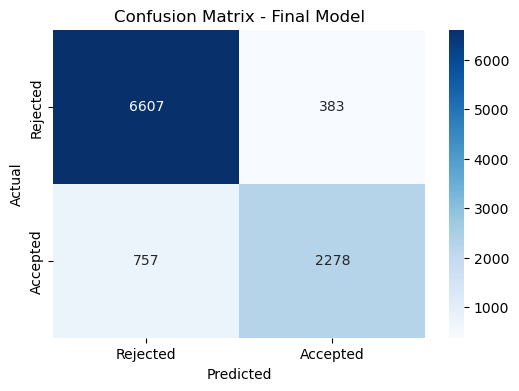

In [61]:
# Final Model Evaluation (Deep Analysis)
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected','Accepted'],
            yticklabels=['Rejected','Accepted'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final Model")
plt.show()


In [62]:
# Precision, Recall, F1 Interpretation
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.90      0.95      0.92      6990
           1       0.86      0.75      0.80      3035

    accuracy                           0.89     10025
   macro avg       0.88      0.85      0.86     10025
weighted avg       0.88      0.89      0.88     10025



In [63]:
# Extract Probability of acceptance
y_prob = model_rf.predict_proba(X_test)[:,1]

In [64]:
# Add Probability to DataFrame
results = X_test.copy()
results['Actual'] = y_test
results['Predicted'] = y_pred_rf
results['Acceptance_Probability'] = y_prob

results.head()

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,academic_band,skills_level,interview_score,degree_norm,skills_norm,interview_norm,experience_norm,Actual,Predicted,Acceptance_Probability
30313,24,1,64.023741,71.531198,66.301513,0,86.934697,65.257235,61.366031,64.256636,...,1,1,71.185988,0.282538,0.350121,0.558522,0.2,1,0,0.32
13902,26,1,63.865265,60.721741,75.762958,0,69.034437,59.871962,58.129156,100.000000,...,2,2,62.345185,0.519074,1.000000,0.379695,0.2,1,0,0.49
509,32,0,69.445500,66.233103,69.625904,0,43.241681,60.292847,65.463470,82.609791,...,1,2,56.332666,0.365648,0.683814,0.258077,0.0,0,0,0.00
45908,22,0,67.056620,62.668928,80.581123,1,69.339892,73.317300,60.681377,84.580406,...,2,2,67.779523,0.639528,0.719644,0.489618,1.0,1,1,0.98
24473,22,1,81.341275,81.026038,73.909390,4,72.705486,71.003816,72.828037,78.667533,...,1,1,72.179113,0.472735,0.612137,0.578611,0.0,0,0,0.09


In [65]:
# Risk Segmentation
def categorize(prob):
    if prob >= 0.75:
        return "High Acceptance Probability"
    elif prob >= 0.40:
        return "Medium Probability"
    else:
        return "High Drop Risk"

results['Risk_Category'] = results['Acceptance_Probability'].apply(categorize)

results['Risk_Category'].value_counts()

Risk_Category
High Drop Risk                 6680
Medium Probability             2033
High Acceptance Probability    1312
Name: count, dtype: int64

In [66]:
# Save Final Production Model
import pickle

with open("final_job_acceptance_model.pkl", "wb") as f:
    pickle.dump(model_rf, f)

print("Final model saved successfully!")

Final model saved successfully!


In [67]:
feature_columns = X_manual.columns.tolist()

with open("feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)


In [68]:
# Analyst Tasks (EDA & ML Analytics)
# Candidate Performance Analysis
sns.set_style("whitegrid")

In [69]:
# Academic Scores vs Placement Outcome
# 📊 Mean Comparison

academic_analysis = df.groupby('status')[[
    'ssc_percentage',
    'hsc_percentage',
    'degree_percentage'
]].mean()

academic_analysis

,ssc_percentage,hsc_percentage,degree_percentage
status,,,
0,70.032126,72.076703,74.039575
1,69.968873,72.027604,73.928515


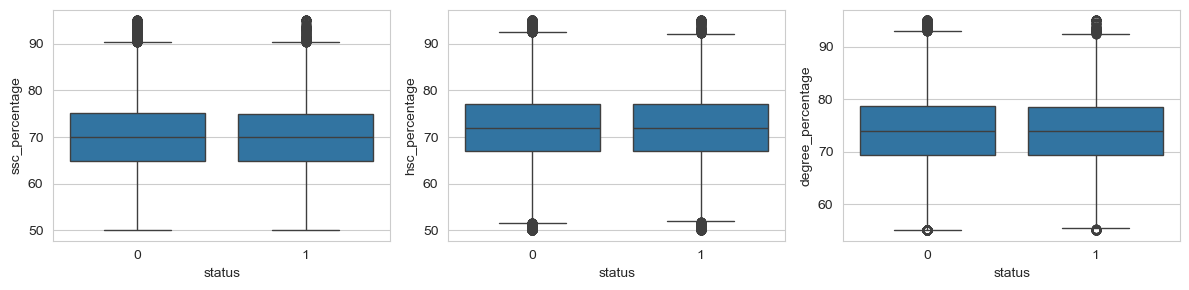

In [70]:
plt.figure(figsize=(12,3))

plt.subplot(1,3,1)
sns.boxplot(x='status', y='ssc_percentage', data=df)

plt.subplot(1,3,2)
sns.boxplot(x='status', y='hsc_percentage', data=df)

plt.subplot(1,3,3)
sns.boxplot(x='status', y='degree_percentage', data=df)

plt.tight_layout()
plt.show()

In [71]:
# Skills Match vs Interview Performance
#  Correlation
df[['skills_match_percentage', 'interview_score']].corr()

,skills_match_percentage,interview_score
skills_match_percentage,1.000000,0.004886
interview_score,0.004886,1.000000


In [72]:
# Mean by Status
df.groupby('status')[[
    'skills_match_percentage',
    'interview_score'
]].mean()

,skills_match_percentage,interview_score
status,,
0,72.398483,64.69412
1,77.495172,69.15323


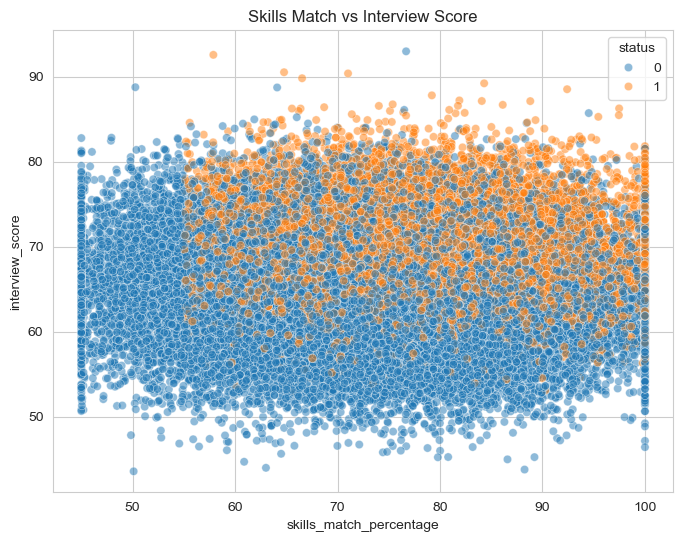

In [73]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='skills_match_percentage',
    y='interview_score',
    hue='status',
    data=df,
    alpha=0.5
)
plt.title("Skills Match vs Interview Score")
plt.show()

In [74]:
# Certification Impact
df.groupby('status')['certifications_count'].mean()

status
0    1.404206
1    1.393832
Name: certifications_count, dtype: float64

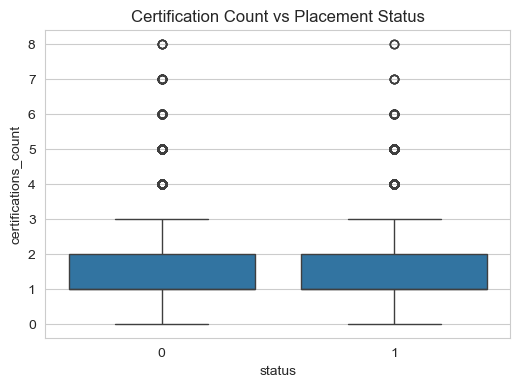

In [75]:
plt.figure(figsize=(6,4))
sns.boxplot(x='status', y='certifications_count', data=df)
plt.title("Certification Count vs Placement Status")
plt.show()

In [76]:
# Acceptance Rate by Company Tier
tier_acceptance = pd.crosstab(
    df['company_tier'],
    df['status'],
    normalize='index'
) * 100

tier_acceptance

status,0,1
company_tier,,
Tier 1,70.048559,29.951441
Tier 2,69.569440,30.430560
Tier 3,69.457162,30.542838


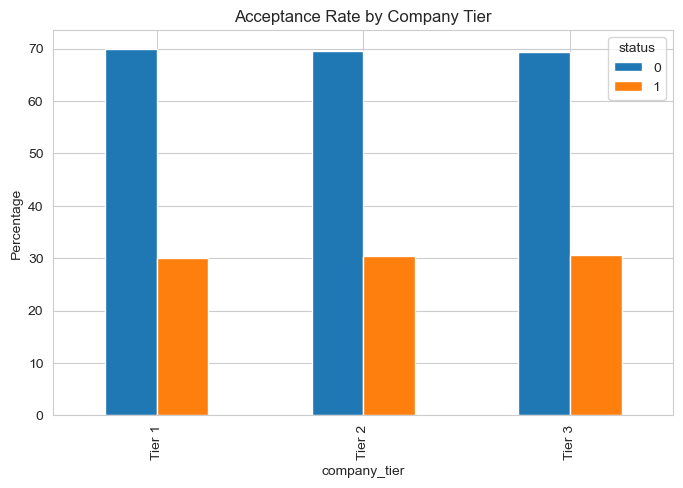

In [77]:
tier_acceptance.plot(kind='bar', figsize=(8,5))
plt.ylabel("Percentage")
plt.title("Acceptance Rate by Company Tier")
plt.show()

In [78]:
# Experience vs Placement Success
df.groupby('experience_category')['status'].mean()


experience_category
Fresher    0.137816
Junior     0.292333
Senior     0.536838
Name: status, dtype: float64

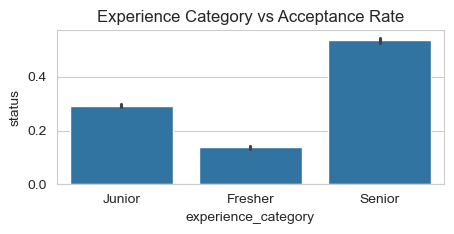

In [79]:
plt.figure(figsize=(5,2))
sns.barplot(x='experience_category', y='status', data=df)
plt.title("Experience Category vs Acceptance Rate")
plt.show()

In [80]:
# Interview Score vs Acceptance Probability (ML Analytical)
df['accept_prob'] = model_rf.predict_proba(X_manual)[:,1]
df['accept_prob']

0        0.01
1        0.09
2        0.38
3        0.01
4        0.10
         ... 
51475    0.00
51480    0.06
51484    0.03
51488    0.98
51497    0.97
Name: accept_prob, Length: 50124, dtype: float64

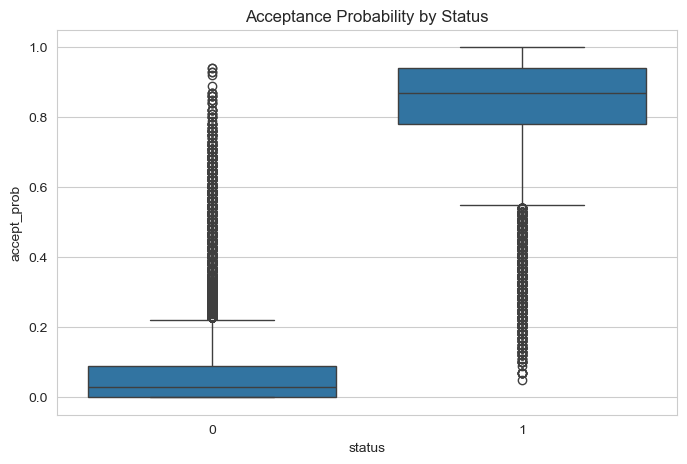

In [81]:
plt.figure(figsize=(8,5))
sns.boxplot(x='status', y='accept_prob', data=df)
plt.title("Acceptance Probability by Status")
plt.show()

In [82]:
# Aptitude Score Analysis
df.groupby('status')['aptitude_score'].mean()

status
0    63.735671
1    64.587091
Name: aptitude_score, dtype: float64

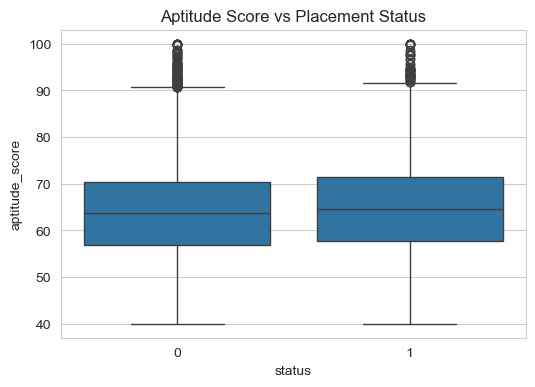

In [83]:
plt.figure(figsize=(6,4))
sns.boxplot(x='status', y='aptitude_score', data=df)
plt.title("Aptitude Score vs Placement Status")
plt.show()

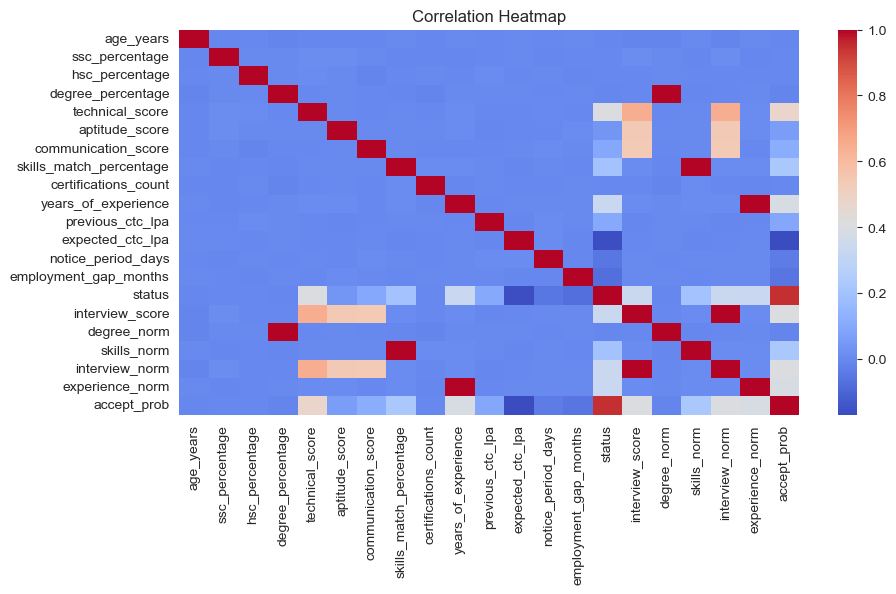

In [84]:
# CORRELATION HEATMAP (ADVANCED EDA)
plt.figure(figsize=(10,5))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm",
    annot=False
)
plt.title("Correlation Heatmap")
plt.show()

In [85]:
# HIGH-RISK CANDIDATE ANALYSIS (ML ANALYTICAL)
def categorize(prob):
    if prob >= 0.75:
        return "High Acceptance"
    elif prob >= 0.40:
        return "Medium Probability"
    else:
        return "High Drop Risk"

df['risk_category'] = df['accept_prob'].apply(categorize)

df['risk_category'].value_counts()

risk_category
High Drop Risk        34633
High Acceptance       12365
Medium Probability     3126
Name: count, dtype: int64

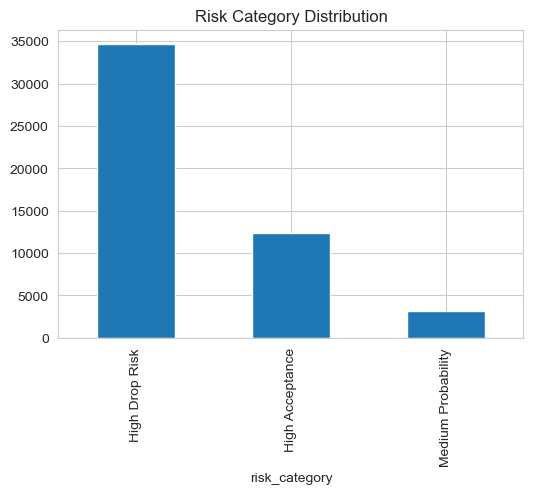

In [86]:
plt.figure(figsize=(6,4))
df['risk_category'].value_counts().plot(kind='bar')
plt.title("Risk Category Distribution")
plt.show()

In [87]:
processed_df=pd.concat([df[['accept_prob','risk_category']],X_manual,y],axis=1)

In [88]:
processed_df.to_csv("Final_data.csv",index=False)

In [89]:
y_pred=model_rf.predict(X_test)
print(pd.Series(y_pred).value_counts())

0    7364
1    2661
Name: count, dtype: int64


In [90]:
df[df["status"] == 1].iloc[0]

age_years                                        33
gender                                       Female
ssc_percentage                            73.892471
hsc_percentage                            68.834121
degree_percentage                          90.19646
degree_specialization        Information Technology
technical_score                           72.445041
aptitude_score                            58.587088
communication_score                       79.494739
skills_match_percentage                    75.46698
certifications_count                              1
internship_experience                           Yes
years_of_experience                               1
career_switch_willingness                   Willing
relevant_experience                        Relevant
previous_ctc_lpa                           5.801817
expected_ctc_lpa                           5.476839
company_tier                                 Tier 3
job_role_match                          Not Matched
competition_